Mapa con pueblos

In [2]:
import pandas as pd
import folium

# 1. Cargar los datos
#Cambiar ruta para que no sea local para que sea ejecutable en todo el proyecto

df_municipios = pd.read_csv('../data/datos_municipios.csv') 
df_candidatos = pd.read_csv('../data/candidatos.csv')

# 2. Crear el mapa centrado en Castilla y León
mapa = folium.Map(location=[41.6, -4.7], zoom_start=7)

# 3. Pintar los Helipuertos (Candidatos) en ROJO
for index, row in df_candidatos.iterrows():
    folium.Marker(
        location=[row['latitud'], row['longitud']],
        popup=row['nombre'],
        icon=folium.Icon(color='red', icon='helicopter', prefix='fa')
    ).add_to(mapa)

# 4. Pintar algunos municipios (ej. los grandes) en AZUL
# Filtramos solo los de más de 1000 habitantes para no saturar el mapa al principio
municipios_grandes = df_municipios[df_municipios['poblacion'] > 1000]

for index, row in municipios_grandes.iterrows():
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=3,
        color='blue',
        fill=True,
        fill_color='blue',
        popup=f"{row['municipio']} (Hab: {row['poblacion']})"
    ).add_to(mapa)

# 5. Guardar el mapa
mapa.save('mapa_inicial_cyl.html')
print("¡Mapa creado! Abre el archivo 'mapa_inicial_cyl.html' en tu navegador.")

¡Mapa creado! Abre el archivo 'mapa_inicial_cyl.html' en tu navegador.


Mapa de calor

In [3]:
import pandas as pd
import folium
from folium.plugins import HeatMap
#Cambiar ruta para que no sea local para que sea ejecutable en todo el proyecto

df_municipios = pd.read_csv('../data/datos_municipios.csv') 
df_candidatos = pd.read_csv('../data/candidatos.csv')

# 2. Crear mapa base
mapa_analisis = folium.Map(location=[41.6, -4.7], zoom_start=7, tiles='CartoDB positron')

# --- TAREA 1: MAPA DE CALOR (DENSIDAD DE POBLACIÓN) ---
# Preparamos los datos: Latitud, Longitud, Peso (Población)
# Normalizamos un poco la población para que el mapa no salga todo rojo
datos_calor = df_municipios[['latitud', 'longitud', 'poblacion']].values.tolist()

# Añadimos la capa de calor
HeatMap(datos_calor, radius=15, blur=20, max_zoom=1).add_to(mapa_analisis)

# --- TAREA 2: RADIOS DE COBERTURA (CÍRCULOS) ---
# Dibujamos un círculo de 40km (40000 metros) alrededor de cada hospital
# Esto simula hasta dónde llega el helicóptero en aprox 15-20 mins.
for index, row in df_candidatos.iterrows():
    # Marcador del hospital
    folium.Marker(
        location=[row['latitud'], row['longitud']],
        popup=row['nombre'],
        icon=folium.Icon(color='red', icon='helicopter', prefix='fa')
    ).add_to(mapa_analisis)
    
    # Círculo de cobertura (Radio en metros)
    folium.Circle(
        location=[row['latitud'], row['longitud']],
        radius=40000,  # 40 km
        color='green',
        fill=True,
        fill_opacity=0.2,
        popup='Cobertura 40km'
    ).add_to(mapa_analisis)

# 3. Guardar
mapa_analisis.save('mapa_analisis_cobertura2.html')
print("¡Mapa de análisis creado! Ábrelo para ver dónde falta cobertura.")

¡Mapa de análisis creado! Ábrelo para ver dónde falta cobertura.


Mapa final de araña

In [ ]:
import pandas as pd
import folium

# 1. Cargar la solución que acabas de generar
try:
    df_solucion = pd.read_csv('..\data\solucion_asignaciones.csv')
except FileNotFoundError:
    print("¡ERROR! Primero tienes que ejecutar el modelo de tus compañeros para generar el CSV.")
    exit()

# 2. Crear mapa base
mapa = folium.Map(location=[41.6, -4.7], zoom_start=7, tiles='CartoDB positron')

# 3. Dibujar las líneas de conexión (Araña)
# Iteramos por cada asignación
for index, row in df_solucion.iterrows():
    
    # Definir color según distancia (Verde: cerca, Rojo: lejos > 45km)
    color_linea = 'green'
    if row['distancia_km'] > 45: # Umbral de 45km (aprox 15-20 min)
        color_linea = 'red'
    elif row['distancia_km'] > 30:
        color_linea = 'orange'
        
    # Dibujar línea
    folium.PolyLine(
        locations=[
            [row['lat_muni'], row['lon_muni']], 
            [row['lat_heli'], row['lon_heli']]
        ],
        color=color_linea,
        weight=0.5,
        opacity=0.4
    ).add_to(mapa)

# 4. Dibujar los Helipuertos ELEGIDOS (Más grandes)
# Agrupamos para no pintar el mismo helipuerto 100 veces
helipuertos_usados = df_solucion[['helipuerto_nombre', 'lat_heli', 'lon_heli']].drop_duplicates()

for index, row in helipuertos_usados.iterrows():
    folium.Marker(
        location=[row['lat_heli'], row['lon_heli']],
        popup=f"BASE ACTIVA: {row['helipuerto_nombre']}",
        icon=folium.Icon(color='blue', icon='helicopter', prefix='fa')
    ).add_to(mapa)

# 5. Guardar
mapa.save('Mapa_Final_Asignaciones.html')
print("¡Mapa generado! Abre 'Mapa_Final_Asignaciones.html'. Las líneas rojas son pueblos lejos.")

¡Mapa generado! Abre 'Mapa_Final_Asignaciones.html'. Las líneas rojas son pueblos lejos.


Crea graficos

C:\Users\Jorge\AppData\Local\Temp\ipykernel_3468\1552554338.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen, x='poblacion', y='helipuerto_nombre', palette='viridis')
C:\Users\Jorge\AppData\Local\Temp\ipykernel_3468\1552554338.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_muni, x='municipio', y='helipuerto_nombre', palette='magma')


Generado: grafico_poblacion_cubierta.png
Generado: grafico_carga_trabajo.png

¡Listo! Pásale las dos imágenes PNG al compañero que hace el informe.


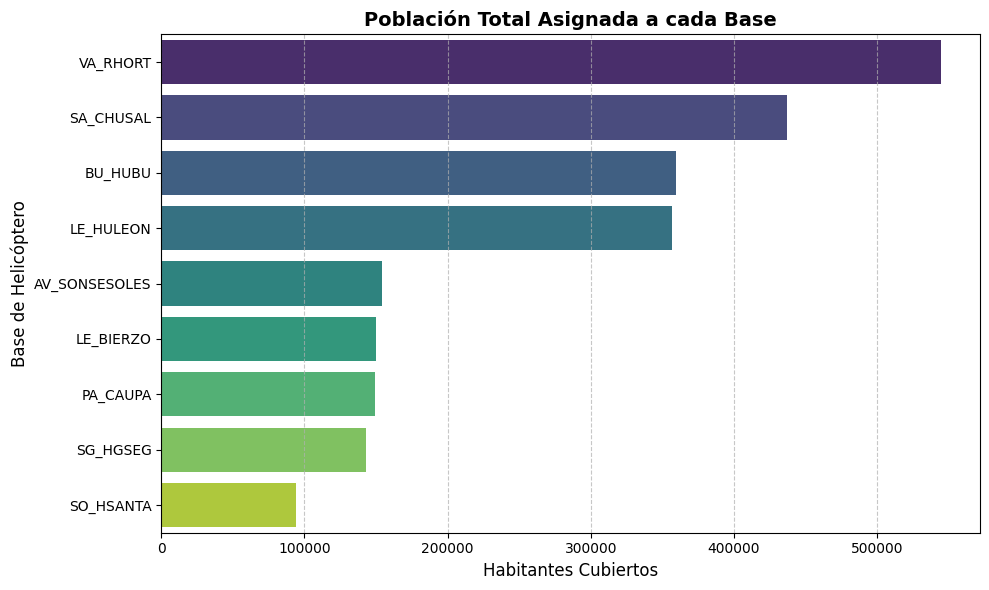

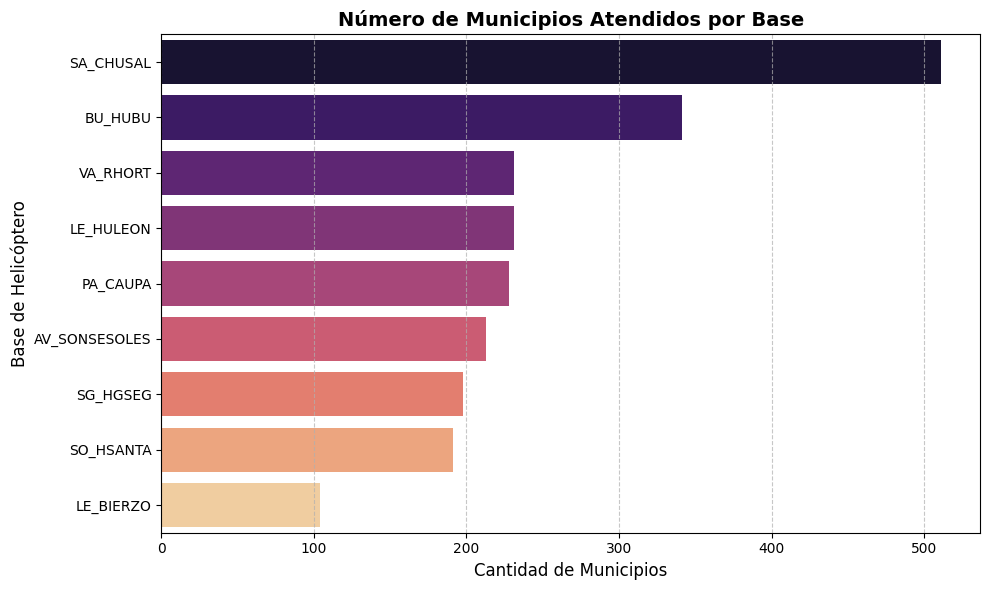

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Si no tienes seaborn: pip install seaborn

# 1. Cargar los archivos
try:
    # Tu solución (la que sale del modelo)
    df_solucion = pd.read_csv('..\data\solucion_asignaciones.csv')
    # Los datos originales (para saber la población de cada pueblo)
    df_datos =pd.read_csv('..\data\datos_municipios.csv') 
except FileNotFoundError:
    print("¡ERROR! Faltan archivos. Asegúrate de tener 'solucion_asignaciones.csv' y 'datos_municipios.csv'.")
    exit()

# 2. Recuperar el dato de POBLACIÓN
# Como en la solución guardamos el nombre del municipio, lo cruzamos con los datos originales
# para "traernos" la columna de población.
df_completo = pd.merge(df_solucion, df_datos[['municipio', 'poblacion']], on='municipio', how='left')

# Si hay algún nulo (nombres que no coinciden), rellenamos con 0 para que no falle
df_completo['poblacion'] = df_completo['poblacion'].fillna(0)

# 3. Calcular las Estadísticas
# Agrupamos por Helipuerto para sumar población y contar pueblos
resumen = df_completo.groupby('helipuerto_nombre').agg({
    'municipio': 'count',   # Cuenta cuántos pueblos
    'poblacion': 'sum'      # Suma cuánta gente vive ahí
}).reset_index()

# Ordenamos para que el gráfico salga bonito (de más a menos población)
resumen = resumen.sort_values('poblacion', ascending=False)

# --- GRÁFICO 1: POBLACIÓN CUBIERTA (El más importante) ---
plt.figure(figsize=(10, 6))
sns.barplot(data=resumen, x='poblacion', y='helipuerto_nombre', palette='viridis')

plt.title('Población Total Asignada a cada Base', fontsize=14, fontweight='bold')
plt.xlabel('Habitantes Cubiertos', fontsize=12)
plt.ylabel('Base de Helicóptero', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Guardar imagen para el informe
plt.tight_layout()
plt.savefig('grafico_poblacion_cubierta.png', dpi=300)
print("Generado: grafico_poblacion_cubierta.png")

# --- GRÁFICO 2: NÚMERO DE MUNICIPIOS (Carga de trabajo) ---
plt.figure(figsize=(10, 6))
# Reordenamos por número de municipios para este segundo gráfico
resumen_muni = resumen.sort_values('municipio', ascending=False)
sns.barplot(data=resumen_muni, x='municipio', y='helipuerto_nombre', palette='magma')

plt.title('Número de Municipios Atendidos por Base', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Municipios', fontsize=12)
plt.ylabel('Base de Helicóptero', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Guardar imagen
plt.tight_layout()
plt.savefig('grafico_carga_trabajo.png', dpi=300)
print("Generado: grafico_carga_trabajo.png")

print("\n¡Listo! Pásale las dos imágenes PNG al compañero que hace el informe.")